# QIS Cash Equities Demo — Vol Target, Decrement, and Attribution

#### Libs, Cleaning, Returns

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats


import numba as nb
from numba import float64
from tqdm import tqdm
from scipy import optimize, spatial
from joblib import Parallel, delayed

from datetime import datetime


In [7]:
equity_raw_data = pd.read_csv('./WIKI_PRICES_212b326a081eacca455e13140d7bb9db 2.csv')
equity_raw_data['date'] = pd.to_datetime(equity_raw_data['date'])
price = equity_raw_data[equity_raw_data['date'] > '1990-01-01']
price = price[['ticker','date','adj_close']].pivot(index = 'date',columns='ticker',values ='adj_close')

In [8]:
limit = 21 # Au délà d'un mois de trading sans données on considère que le stock n'est plus listé
equity_prices_filled = price.ffill(limit=limit) # Lisser les returns 
rets = (equity_prices_filled/equity_prices_filled.shift(1)-1) # returns en %
rets = rets[price.notna()] # Applique un masque pour garder les returns calculer sur les prix lissés quand dans les jours ou les marchés sont ouverts
rets

ticker,A,AA,AAL,AAMC,AAN,AAOI,AAON,AAP,AAPL,AAT,...,ALLE,ALNY,ALOG,ALR,ALSN,ALTR,ALX,ALXN,AMAG,AMAT
date,,,,,,,,,,,,,,,,,,,,,
1990-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03,NaN,NaN,NaN,NaN,0.063000,NaN,NaN,NaN,0.006711,NaN,...,NaN,NaN,0.026667,NaN,NaN,0.017931,-0.017895,NaN,0.014493,-0.025641
1990-01-04,NaN,NaN,NaN,NaN,0.011289,NaN,NaN,NaN,0.003467,NaN,...,NaN,NaN,-0.012987,NaN,NaN,0.016260,-0.004555,NaN,-0.014286,-0.013333
1990-01-05,NaN,NaN,NaN,NaN,-0.069767,NaN,NaN,NaN,0.003189,NaN,...,NaN,NaN,0.013158,NaN,NaN,-0.016000,-0.002380,NaN,-0.028986,-0.013158
1990-01-08,NaN,NaN,NaN,NaN,-0.013000,NaN,NaN,NaN,0.006623,NaN,...,NaN,NaN,-0.012987,NaN,NaN,0.000000,-0.002202,NaN,-0.029851,-0.018018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-03-21,-0.006442,0.031849,-0.022234,0.000000,-0.003576,0.001500,-0.005096,0.008665,-0.022655,-0.013074,...,0.003620,-0.015349,0.000000,NaN,0.006148,NaN,-0.009251,-0.019381,0.007692,NaN
2018-03-22,-0.027810,-0.063191,-0.032908,-0.010197,-0.030188,-0.028079,-0.012804,-0.030632,-0.014159,0.001848,...,-0.015592,-0.025708,-0.009631,NaN,-0.033350,NaN,0.007593,-0.031046,-0.002545,NaN
2018-03-23,-0.020898,-0.004675,-0.024852,-0.030409,-0.013931,-0.023112,-0.035019,-0.007788,-0.023128,-0.022755,...,-0.019385,-0.031158,-0.010265,NaN,-0.013695,NaN,-0.007723,-0.030115,-0.017857,NaN


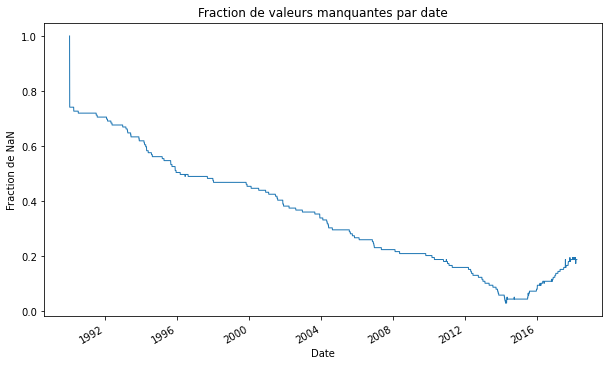

In [9]:
fraction_nan = rets.isna().mean(axis=1)

plt.figure(figsize=(10, 6))
fraction_nan.plot(title="Fraction de valeurs manquantes par date", lw=1)
plt.xlabel("Date")
plt.ylabel("Fraction de NaN")
plt.show()

In [10]:
equity_returns_clean = rets.dropna(thresh=int(0.75 * rets.shape[1])) # Supprimer les lignes où moins de 75% des stocks ont des valeurs pour enlever les jours fériés
equity_prices_clean = equity_prices_filled[equity_returns_clean.columns]

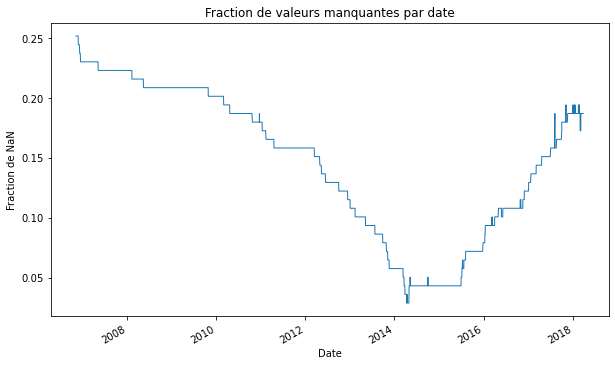

In [11]:
fraction_nan = equity_returns_clean.isna().mean(axis=1)
plt.figure(figsize=(10, 6))
fraction_nan.plot(title="Fraction de valeurs manquantes par date", lw=1)
plt.xlabel("Date")
plt.ylabel("Fraction de NaN")
plt.show()

In [12]:
equity_prices_clean = equity_prices_clean.loc["2000":].copy()
equity_prices_clean

ticker,A,AA,AAL,AAMC,AAN,AAOI,AAON,AAP,AAPL,AAT,...,ALLE,ALNY,ALOG,ALR,ALSN,ALTR,ALX,ALXN,AMAG,AMAT
date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,49.121329,NaN,NaN,NaN,4.975857,NaN,1.025920,NaN,3.596463,NaN,...,NaN,NaN,29.235869,3.44,NaN,23.651391,42.804794,7.3750,4.120,NaN
2000-01-04,45.369006,NaN,NaN,NaN,4.958913,NaN,1.068476,NaN,3.293170,NaN,...,NaN,NaN,29.509431,3.50,NaN,22.465213,42.875681,6.9375,3.938,NaN
2000-01-05,41.998737,NaN,NaN,NaN,4.958913,NaN,1.073796,NaN,3.341362,NaN,...,NaN,NaN,29.288817,3.50,NaN,21.675932,42.908398,7.1575,3.875,NaN
2000-01-06,40.934441,NaN,NaN,NaN,4.958913,NaN,1.082915,NaN,3.052206,NaN,...,NaN,NaN,28.847587,3.50,NaN,21.648871,42.837511,7.7500,4.000,NaN
2000-01-07,44.345645,NaN,NaN,NaN,4.958913,NaN,1.044918,NaN,3.196784,NaN,...,NaN,NaN,29.288817,3.44,NaN,23.903961,43.148323,8.2500,4.125,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-03-21,69.400000,47.95,54.09,60.80,47.370000,26.71,39.050000,115.24,171.270000,32.46,...,85.94,146.26,93.450000,NaN,39.28,29.980000,372.690000,117.8900,19.650,NaN
2018-03-22,67.470000,44.92,52.31,60.18,45.940000,25.96,38.550000,111.71,168.845000,32.52,...,84.60,142.50,92.550000,NaN,37.97,29.980000,375.520000,114.2300,19.600,NaN
2018-03-23,66.060000,44.71,51.01,58.35,45.300000,25.36,37.200000,110.84,164.940000,31.78,...,82.96,138.06,91.600000,NaN,37.45,29.980000,372.620000,110.7900,19.250,NaN


In [17]:
def get_Act(price):
    return pd.Series((price.index[1:].astype('datetime64[ns]') - price.index[:-1].astype('datetime64[ns]')),index=price.index[1:]).dt.days.rename('day_count_act').reindex(price.index)

In [18]:
print(equity_prices_clean.columns)

Index(['A', 'AA', 'AAL', 'AAMC', 'AAN', 'AAOI', 'AAON', 'AAP', 'AAPL', 'AAT',
       ...
       'ALLE', 'ALNY', 'ALOG', 'ALR', 'ALSN', 'ALTR', 'ALX', 'ALXN', 'AMAG',
       'AMAT'],
      dtype='object', name='ticker', length=139)


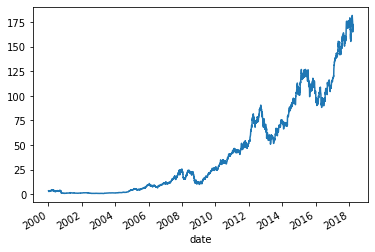

In [19]:
equity_prices_clean['AAPL'].plot()
equity_prices_clean['AMAT'].plot()

act =  get_Act(equity_prices_clean['AAPL'])

In [20]:
market_rates_fx = pd.read_csv("rates_fx_separate_usd_eur_with_hist_fx.csv", sep=",", index_col=0, parse_dates=True)
market_rates_fx = market_rates_fx
market_rates_fx = market_rates_fx.reindex(equity_prices_clean.index)

market_rates_fx["eurusd_fx_rate"] = 1/market_rates_fx["eurusd_fx_rate"].ffill(limit=5)

market_rates_fx["usd_rf_3m"] = market_rates_fx["usd_rf_3m"].ffill(limit=5)/100
market_rates_fx["eur_rf_overnight"] = market_rates_fx["eur_rf_overnight"].ffill(limit=5)/100

In [21]:
market_rates_fx[["usd_rf_3m", "eur_rf_overnight", "eurusd_fx_rate"]].loc['2000':]

,usd_rf_3m,eur_rf_overnight,eurusd_fx_rate
date,,,
2000-01-03,0.0642,0.03060,0.974469
2000-01-04,0.0634,0.03010,0.970120
2000-01-05,0.0643,0.02990,0.969556
2000-01-06,0.0639,0.02920,0.969086
2000-01-07,0.0635,0.02890,0.971912
...,...,...,...
2018-03-21,0.0246,-0.00367,0.810209
2018-03-22,0.0243,-0.00368,0.811662
2018-03-23,0.0241,-0.00366,0.809474


In [22]:
usd_rf_curve = market_rates_fx['usd_rf_3m'].copy()
eurusd_spot = market_rates_fx["eurusd_fx_rate"].copy()

In [23]:
def excess_returnize(price, rate):
    day_count_act = get_Act(price)
    underlier_excess_usd = price.pct_change(1, fill_method=None).add(1).subtract(rate.shift(1) * day_count_act / 360, axis=0).fillna(1).cumprod().multiply(price.bfill().iloc[0]).loc[price.index[0]:]*price.notna().replace(False,np.nan)

    if isinstance(underlier_excess_usd, pd.Series):
        return underlier_excess_usd.rename(price.name)
    return underlier_excess_usd

def rebase_level(price, base_date=None, base_value=1000.0):
    if base_date is None:
        base_date_nearest = price.index[0]
    else:
        base_date_nearest = price.index[price.index.get_indexer([base_date], method='nearest')][0]
        if base_date_nearest != base_date:
            print('The Base Date has changed :', base_date.strftime('%Y-%m-%d'), 'to', base_date_nearest.strftime('%Y-%m-%d'))
    return base_value * price / price.loc[base_date_nearest]

def compute_VT_level(price, underlier_name, target_vol, return_lag_days, hist_vol_lookback_days, max_exposure, exposure_lag_days, inst_vol_lookback_days, vaf_lookforward_days, vaf_floor=1, vaf_cap=1, repo_cost=0, tx_cost=0, struct_fee=0):
    calc_frame = price.copy() if isinstance(price, pd.DataFrame) else price.to_frame().copy()

    calc_frame['day_count_act'] = get_Act(price)
    day_count_rolling = calc_frame['day_count_act'].rolling(return_lag_days).sum()
    calc_frame['N'] = 1
    calc_frame['HV'] = np.sqrt((np.log(calc_frame[underlier_name].pct_change(return_lag_days) + 1)**2 * 365 / day_count_rolling).rolling(hist_vol_lookback_days).mean())
    calc_frame['Expo'] = np.minimum(max_exposure, (target_vol / calc_frame['HV'] * 1.0).shift(exposure_lag_days))
    calc_frame['tx_cost'] = tx_cost * np.abs(1000 * calc_frame['Expo'])
    calc_frame['VAF'] = 1.0
    calc_frame['adaptive_window'] = 0
    calc_frame['IHV'] = np.nan
    calc_frame['IL'] = 1000.0

    vt_inception_date = calc_frame.index[hist_vol_lookback_days + return_lag_days + exposure_lag_days - 1]
    previous_rebalance_date = vt_inception_date

    for t in tqdm(calc_frame.index):
        if t > vt_inception_date:
            expo_lag_date = calc_frame.loc[:t].index[-exposure_lag_days - 1]
            return_lag_date = calc_frame.loc[:t].index[-return_lag_days - 1]

            calc_frame.loc[t, 'IL'] = calc_frame.loc[previous_rebalance_date, 'IL'] * (
                1 + calc_frame.loc[previous_rebalance_date, 'Expo'] * (
                    calc_frame.loc[t, underlier_name] / calc_frame.loc[previous_rebalance_date, underlier_name] - 1.0 - repo_cost * calc_frame['day_count_act'].loc[t] / 360
                ) - struct_fee * calc_frame['day_count_act'].loc[t] / 365 - calc_frame.loc[previous_rebalance_date, 'tx_cost']
            )

            adaptive_window = np.minimum(inst_vol_lookback_days, calc_frame.loc[vt_inception_date:t, 'N'].sum().astype(int) - 1)
            calc_frame.loc[t, 'adaptive_window'] = adaptive_window
            adaptive_window_start = calc_frame.loc[:t].index[-adaptive_window]
            adaptive_window_start_lag = calc_frame.loc[:t].index[-adaptive_window - return_lag_days]

            calc_frame.loc[t, 'IHV'] = np.sqrt(np.mean(
                np.log(calc_frame.loc[adaptive_window_start:t, 'IL'].values / calc_frame.loc[adaptive_window_start_lag:return_lag_date, 'IL'].values)**2
                * 365 / day_count_rolling.loc[adaptive_window_start:t]
            ))

            calc_frame.loc[t, 'VAF'] = np.clip(np.sqrt(np.maximum(0.0, 1 + adaptive_window / vaf_lookforward_days * (1 - (calc_frame.loc[t, 'IHV'] / target_vol)**2))), vaf_floor, vaf_cap)
            calc_frame.loc[t, 'Expo'] = np.clip(target_vol / calc_frame.loc[expo_lag_date, 'HV'] * calc_frame.loc[expo_lag_date, 'VAF'], 0, max_exposure)
            calc_frame.loc[t, 'tx_cost'] = tx_cost * np.abs(
                calc_frame.loc[t, 'Expo'] * calc_frame.loc[t, 'IL'] - calc_frame.loc[previous_rebalance_date, 'Expo'] * calc_frame.loc[previous_rebalance_date, 'IL'] * calc_frame.loc[t, underlier_name] / calc_frame.loc[previous_rebalance_date, underlier_name]
            )

            previous_rebalance_date = t

    calc_frame[underlier_name] = rebase_level(calc_frame[underlier_name], vt_inception_date, 1000.0)
    return calc_frame.rename(columns={'IL': f'Vol Target {int(100 * target_vol)}%'}), vt_inception_date

def compute_stats(price, return_lag_days, names=None, rounding=2):
    @nb.jit(nb.float64(nb.float64[:]), nopython=True, parallel=True)
    def get_max_dd(nvs):
        n = nvs.size
        peak_series = np.zeros(n)
        for i in nb.prange(0, n):
            peak_series[i] = np.max(nvs[np.maximum(0, i - n):i + 1])
        return np.min(nvs / peak_series - 1.0)

    day_count_act = get_Act(price)
    day_count_rolling = day_count_act.rolling(return_lag_days).sum()
    if names is None:
        names = price.columns
    perf_stats = pd.DataFrame(columns=names)
    log_returns = np.log(price[names].pct_change(return_lag_days, fill_method=None) + 1)
    perf_stats.loc['Return p.a. (%)'] = ((price[names].ffill().iloc[-1] / price[names].bfill().iloc[0])**(365 / (day_count_act.sum() - 1)) - 1) * 100
    perf_stats.loc['Vol p.a. (%)'] = np.sqrt((log_returns**2).multiply(365 / day_count_rolling, axis='index').mean()) * 100
    perf_stats.loc['Sharpe p.a.'] = perf_stats.loc['Return p.a. (%)'] / perf_stats.loc['Vol p.a. (%)']
    perf_stats.loc['Sortino p.a.'] = perf_stats.loc['Return p.a. (%)'] / np.sqrt((log_returns.mask(log_returns.le(0))**2).multiply(365 / day_count_rolling, axis='index').dropna().mean() * 10000)
    perf_stats.loc['rolling_mdd (%)'] = price[names].apply(lambda x: get_max_dd(x), raw=True) * 100
    rolling_mdd = -price[names].rolling(window=252, step=5).apply(get_max_dd, engine='numba', raw=True)
    perf_stats.loc['Med 1Y rolling_mdd (%)'] = rolling_mdd.median() * 100
    perf_stats.loc['Avg 1Y rolling_mdd (%)'] = rolling_mdd.mean() * 100
    return perf_stats.round(rounding)

def compute_decrement_points(price, fixed_decrement_points, base_date, base_value, ACT_convention=365):
    decremented_levels = price.multiply(0).add(base_value)
    day_count_act = get_Act(price)
    base_date_nearest = price.index[price.index.get_indexer([base_date], method='nearest')][0]
    if base_date_nearest != base_date:
        print('The Base Date has changed :', base_date.strftime('%Y-%m-%d'), 'to', base_date_nearest.strftime('%Y-%m-%d'))
    previous_rebalance_date = base_date_nearest
    for t in price[price.index >= base_date_nearest].index:
        if t > base_date_nearest:
            decremented_levels.loc[t] = decremented_levels.loc[previous_rebalance_date] * price.loc[t] / price.loc[previous_rebalance_date] - fixed_decrement_points * day_count_act.loc[t] / ACT_convention
        previous_rebalance_date = t
    next_rebalance_date = base_date_nearest
    for t in price[price.index <= base_date_nearest].index[::-1]:
        if t < base_date_nearest:
            decremented_levels.loc[t] = (decremented_levels.loc[next_rebalance_date] + fixed_decrement_points * day_count_act.loc[next_rebalance_date] / ACT_convention) * (price.loc[t] / price.loc[next_rebalance_date])
        next_rebalance_date = t
    return decremented_levels

def compute_decrement_synthetic(price, SD, ACT_convention=365):
    day_count_act = get_Act(price)
    if SD > 1:
        SD /= 100
    synthetic_decrement_factor = (1.0 - SD * day_count_act / ACT_convention)
    return price.pct_change(1).add(1).multiply(synthetic_decrement_factor, axis=0).fillna(1000).cumprod()

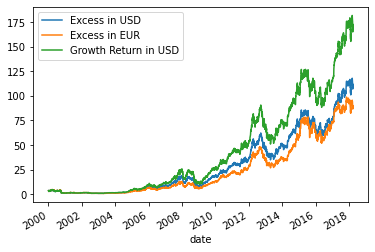

In [24]:
underlier_excess_usd = excess_returnize(equity_prices_clean['AAPL'], usd_rf_curve)
underlier_excess_eur = underlier_excess_usd.multiply(eurusd_spot)


ax = underlier_excess_usd.plot(label='Excess in USD')
underlier_excess_eur.plot(ax=ax, label='Excess in EUR')
equity_prices_clean['AAPL'].plot(ax=ax, label='Growth Return in USD')

ax.legend()
plt.show()

In [25]:
underlier_excess_eur = pd.Series(underlier_excess_eur, name="AAPL ER EUR")

In [26]:
underlier_name = 'AAPL ER EUR'
target_vol = 0.15
return_lag_days=2

hist_vol_lookback_days = 21*6
max_exposure=2
exposure_lag_days=1
inst_vol_lookback_days=21

vaf_lookforward_days=21
vaf_floor=1
vaf_cap=1
repo_cost=0
tx_cost=0
struct_fee=1.2/1e4


vt_diagnostics, vt_inception_date = compute_VT_level(underlier_excess_eur, underlier_name, target_vol, return_lag_days, hist_vol_lookback_days, max_exposure, exposure_lag_days, inst_vol_lookback_days,vaf_lookforward_days, vaf_floor, vaf_cap, repo_cost, tx_cost, struct_fee)

100%|██████████| 4586/4586 [00:11<00:00, 386.67it/s]


In [27]:
vt_diagnostics

,AAPL ER EUR,day_count_act,N,HV,Expo,tx_cost,VAF,adaptive_window,IHV,Vol Target 15%
date,,,,,,,,,,
2000-01-03,1034.792295,NaN,1,NaN,NaN,NaN,1.0,0,NaN,1000.000000
2000-01-04,943.115232,1.0,1,NaN,NaN,NaN,1.0,0,NaN,1000.000000
2000-01-05,956.194252,1.0,1,NaN,NaN,NaN,1.0,0,NaN,1000.000000
2000-01-06,872.852745,1.0,1,NaN,NaN,NaN,1.0,0,NaN,1000.000000
2000-01-07,916.708579,1.0,1,NaN,NaN,NaN,1.0,0,NaN,1000.000000
...,...,...,...,...,...,...,...,...,...,...
2018-03-21,26558.348535,1.0,1,0.245291,0.615805,0.0,1.0,21,0.141893,8177.675060
2018-03-22,26227.457772,1.0,1,0.250598,0.611519,0.0,1.0,21,0.162115,8114.930649
2018-03-23,25550.048553,1.0,1,0.254507,0.598568,0.0,1.0,21,0.176222,7986.757080


<AxesSubplot:xlabel='date'>

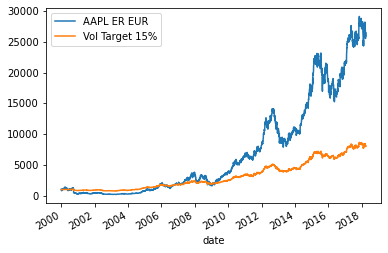

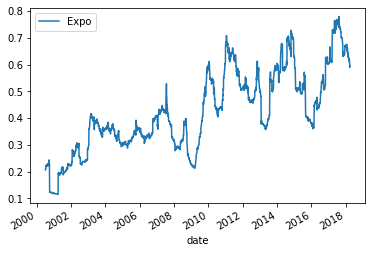

In [28]:
vt_diagnostics[['AAPL ER EUR', f'Vol Target {int(target_vol*100)}%']].plot()
vt_diagnostics[['Expo']].plot()

In [29]:
perf_stats = compute_stats(vt_diagnostics[['AAPL ER EUR', f'Vol Target {int(target_vol*100)}%']], return_lag_days)
perf_stats

TypeError: rolling() got an unexpected keyword argument 'step'

In [ ]:
fixed_decrement_points = 30
base_date = pd.to_datetime('2010-03-21')
base_value = 1000

decremented_index_levels = compute_decrement_points(vt_diagnostics[[f'Vol Target {int(target_vol*100)}%']], fixed_decrement_points, base_date, base_value)

In [4]:
decremented_index_levels.plot()

NameError: name 'decremented_index_levels' is not defined